In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)

print("Phase 3 libraries imported successfully.")

Phase 3 libraries imported successfully.


In [2]:
PROJECT_ROOT = Path("..")

TRAIN_PATH = PROJECT_ROOT / "data" / "raw" / "train.csv"

train_df = pd.read_csv(TRAIN_PATH)

train_df["date"] = pd.to_datetime(train_df["date"])


def create_date_features(df):
    df = df.copy()

    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["day_of_week"] = df["date"].dt.dayofweek
    df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
    df["quarter"] = df["date"].dt.quarter
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

    return df


train_df = create_date_features(train_df)

model_df = (
    train_df
    .sort_values(["store", "date"])
    .reset_index(drop=True)
)

model_df["sales_lag_1"] = (
    model_df
    .groupby("store")["sales"]
    .shift(1)
)

model_df["sales_lag_7"] = (
    model_df
    .groupby("store")["sales"]
    .shift(7)
)

model_df["sales_rolling_mean_7"] = (
    model_df
    .groupby("store")["sales"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

lag_features = [
    "sales_lag_1",
    "sales_lag_7",
    "sales_rolling_mean_7"
]

model_df = (
    model_df
    .dropna(subset=lag_features)
    .sort_values(["date", "store"])
    .reset_index(drop=True)
)

print("Processed data shape:", model_df.shape)

Processed data shape: (5079, 23)


In [3]:
unique_dates = np.sort(
    model_df["date"].unique()
)

split_index = int(len(unique_dates) * 0.80)

split_date = unique_dates[split_index]

train_model = model_df[
    model_df["date"] < split_date
].copy()

validation_model = model_df[
    model_df["date"] >= split_date
].copy()

print("Split date:", split_date)

print(
    "\nTraining:",
    train_model["date"].min(),
    "to",
    train_model["date"].max()
)

print(
    "Validation:",
    validation_model["date"].min(),
    "to",
    validation_model["date"].max()
)

print("\nTraining shape:", train_model.shape)
print("Validation shape:", validation_model.shape)

Split date: 2023-06-16T00:00:00.000000

Training: 2021-08-09 00:00:00 to 2023-06-15 00:00:00
Validation: 2023-06-16 00:00:00 to 2023-11-30 00:00:00

Training shape: (3682, 23)
Validation shape: (1397, 23)


In [4]:
TARGET = "sales"

MODEL_FEATURES = [
    "store",
    "is_state_holiday",
    "is_school_holiday",
    "is_special_day",
    "temperature_max",
    "temperature_min",
    "temperature_mean",
    "sunshine_sum",
    "precipitation_sum",
    "year",
    "month",
    "day",
    "day_of_week",
    "week_of_year",
    "quarter",
    "is_weekend",
    "sales_lag_1",
    "sales_lag_7",
    "sales_rolling_mean_7"
]

categorical_features = [
    "store",
    "is_state_holiday",
    "is_school_holiday",
    "is_special_day"
]

numerical_features = [
    col for col in MODEL_FEATURES
    if col not in categorical_features
]

X_train = train_model[MODEL_FEATURES]
y_train = train_model[TARGET]

X_validation = validation_model[MODEL_FEATURES]
y_validation = validation_model[TARGET]

print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)

X_train: (3682, 19)
X_validation: (1397, 19)


In [5]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numerical_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline ready.")

Preprocessing pipeline ready.


In [6]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_validation
)

print("Linear Regression training complete.")

Linear Regression training complete.


In [7]:
linear_mae = mean_absolute_error(
    y_validation,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_validation,
    linear_predictions
)

print("LINEAR REGRESSION")
print("=" * 40)
print(f"MAE  : {linear_mae:.4f}")
print(f"RMSE : {linear_rmse:.4f}")
print(f"R²   : {linear_r2:.4f}")

LINEAR REGRESSION
MAE  : 0.2686
RMSE : 0.3475
R²   : 0.8001


In [8]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=15,
                min_samples_leaf=2,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

rf_predictions = random_forest_model.predict(
    X_validation
)

print("Random Forest training complete.")

Random Forest training complete.


In [9]:
rf_mae = mean_absolute_error(
    y_validation,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_validation,
    rf_predictions
)

print("RANDOM FOREST")
print("=" * 40)
print(f"MAE  : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")

RANDOM FOREST
MAE  : 0.2882
RMSE : 0.3667
R²   : 0.7775


In [10]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBRegressor(
                n_estimators=500,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_predictions = xgb_model.predict(
    X_validation
)

print("XGBoost training complete.")

XGBoost training complete.


In [11]:
xgb_mae = mean_absolute_error(
    y_validation,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        xgb_predictions
    )
)

xgb_r2 = r2_score(
    y_validation,
    xgb_predictions
)

print("XGBOOST")
print("=" * 40)
print(f"MAE  : {xgb_mae:.4f}")
print(f"RMSE : {xgb_rmse:.4f}")
print(f"R²   : {xgb_r2:.4f}")

XGBOOST
MAE  : 0.3554
RMSE : 0.4815
R²   : 0.6163


In [12]:
baseline_predictions = validation_model["sales_lag_7"]

baseline_mae = mean_absolute_error(
    y_validation,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_validation,
    baseline_predictions
)

results = pd.DataFrame({
    "Model": [
        "Weekly Lag Baseline",
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2": [
        baseline_r2,
        linear_r2,
        rf_r2,
        xgb_r2
    ]
})

results = results.sort_values(
    "MAE"
).reset_index(drop=True)

results.round(4)

,Model,MAE,RMSE,R2
0,Weekly Lag Baseline,0.2593,0.3830,0.7572
1,Linear Regression,0.2686,0.3475,0.8001
2,Random Forest,0.2882,0.3667,0.7775
3,XGBoost,0.3554,0.4815,0.6163


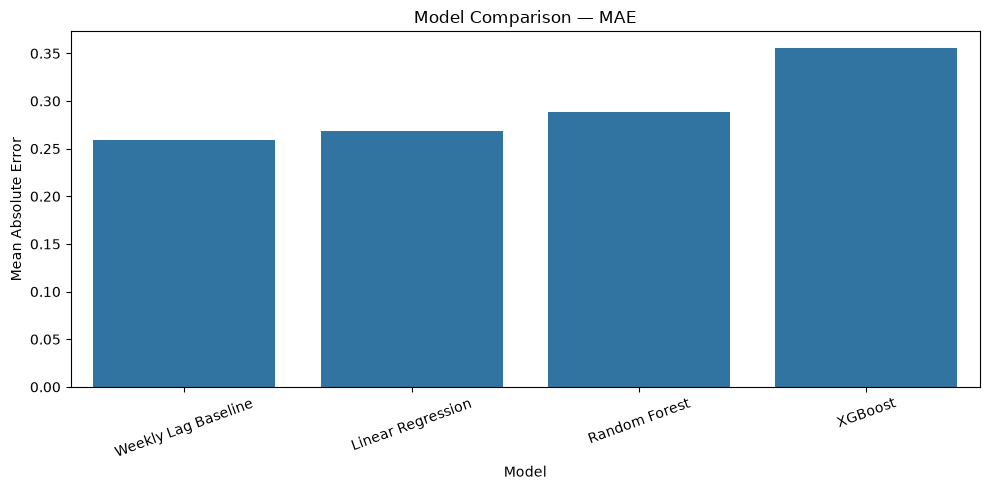

In [13]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results,
    x="Model",
    y="MAE"
)

plt.title("Model Comparison — MAE")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [19]:
results = pd.DataFrame([
    {
        "Model": "Weekly Lag Baseline",
        "MAE": baseline_mae,
        "RMSE": baseline_rmse,
        "R2": baseline_r2
    },
    {
        "Model": "Linear Regression",
        "MAE": linear_mae,
        "RMSE": linear_rmse,
        "R2": linear_r2
    },
    {
        "Model": "Random Forest",
        "MAE": rf_mae,
        "RMSE": rf_rmse,
        "R2": rf_r2
    },
    {
        "Model": "XGBoost",
        "MAE": xgb_mae,
        "RMSE": xgb_rmse,
        "R2": xgb_r2
    }
])

results = results.sort_values("MAE").reset_index(drop=True)

print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

display(results)

MODEL COMPARISON


,Model,MAE,RMSE,R2
0,Weekly Lag Baseline,0.259293,0.382989,0.757241
1,Linear Regression,0.268576,0.347522,0.800121
2,Random Forest,0.288236,0.366653,0.777508
3,XGBoost,0.355372,0.481483,0.616323


In [20]:
ml_results = results[
    results["Model"] != "Weekly Lag Baseline"
].copy()

ml_results = ml_results.sort_values("MAE").reset_index(drop=True)

candidate_name = ml_results.iloc[0]["Model"]

trained_models = {
    "Linear Regression": linear_model,
    "Random Forest": random_forest_model,
    "XGBoost": xgb_model
}

candidate_model = trained_models[candidate_name]
candidate_row = ml_results.iloc[0]

print("=" * 70)
print("SELECTED ML CANDIDATE")
print("=" * 70)

print("Model:", candidate_name)
print(f"MAE  : {candidate_row['MAE']:.4f}")
print(f"RMSE : {candidate_row['RMSE']:.4f}")
print(f"R²   : {candidate_row['R2']:.4f}")

print("\n" + "=" * 70)
print("BASELINE BENCHMARK")
print("=" * 70)

print(f"MAE  : {baseline_mae:.4f}")
print(f"RMSE : {baseline_rmse:.4f}")
print(f"R²   : {baseline_r2:.4f}")

SELECTED ML CANDIDATE
Model: Linear Regression
MAE  : 0.2686
RMSE : 0.3475
R²   : 0.8001

BASELINE BENCHMARK
MAE  : 0.2593
RMSE : 0.3830
R²   : 0.7572


In [21]:
candidate_predictions = candidate_model.predict(X_validation)

prediction_analysis = validation_model[
    ["date", "store", "sales"]
].copy()

prediction_analysis["predicted_sales"] = candidate_predictions

prediction_analysis["absolute_error"] = (
    prediction_analysis["sales"]
    - prediction_analysis["predicted_sales"]
).abs()

display(prediction_analysis.head(10))

,date,store,sales,predicted_sales,absolute_error
3682,2023-06-16,store_0,-1.416815,-1.427099,0.010284
3683,2023-06-16,store_1,-0.404777,-0.667091,0.262314
3684,2023-06-16,store_3,-0.819853,-0.791618,0.028235
3685,2023-06-16,store_4,-0.355808,-0.435946,0.080139
3686,2023-06-16,store_5,-0.250873,-0.376016,0.125143
3687,2023-06-16,store_6,-1.248919,-1.265988,0.017068
3688,2023-06-16,store_7,1.008345,0.318017,0.690327
3689,2023-06-16,store_8,0.511653,0.102174,0.409480
3690,2023-06-17,store_0,-1.332867,-1.021560,0.311308
3691,2023-06-17,store_1,0.096578,-0.069422,0.166000


In [22]:
print("=" * 70)
print("PREDICTION ERROR ANALYSIS")
print("=" * 70)

print(f"Mean Absolute Error : {prediction_analysis['absolute_error'].mean():.4f}")
print(f"Maximum Error       : {prediction_analysis['absolute_error'].max():.4f}")
print(f"Minimum Error       : {prediction_analysis['absolute_error'].min():.4f}")

print("\nLargest prediction errors:")

display(
    prediction_analysis
    .sort_values("absolute_error", ascending=False)
    .head(10)
)

PREDICTION ERROR ANALYSIS
Mean Absolute Error : 0.2686
Maximum Error       : 1.3949
Minimum Error       : 0.0003

Largest prediction errors:


,date,store,sales,predicted_sales,absolute_error
4628,2023-10-11,store_8,-1.241924,0.153016,1.394940
3792,2023-06-29,store_7,-0.880482,0.478587,1.359069
3800,2023-06-30,store_7,-1.041382,0.291586,1.332967
4306,2023-09-02,store_1,1.425752,0.103588,1.322164
4064,2023-08-02,store_7,-0.733573,0.512971,1.246544
4072,2023-08-03,store_7,-1.039050,0.158425,1.197474
4556,2023-10-03,store_4,1.075969,-0.084204,1.160173
4120,2023-08-09,store_7,1.152922,0.032320,1.120602
4312,2023-09-02,store_8,1.857151,0.737113,1.120038
3912,2023-07-14,store_7,-0.752228,0.329769,1.081997


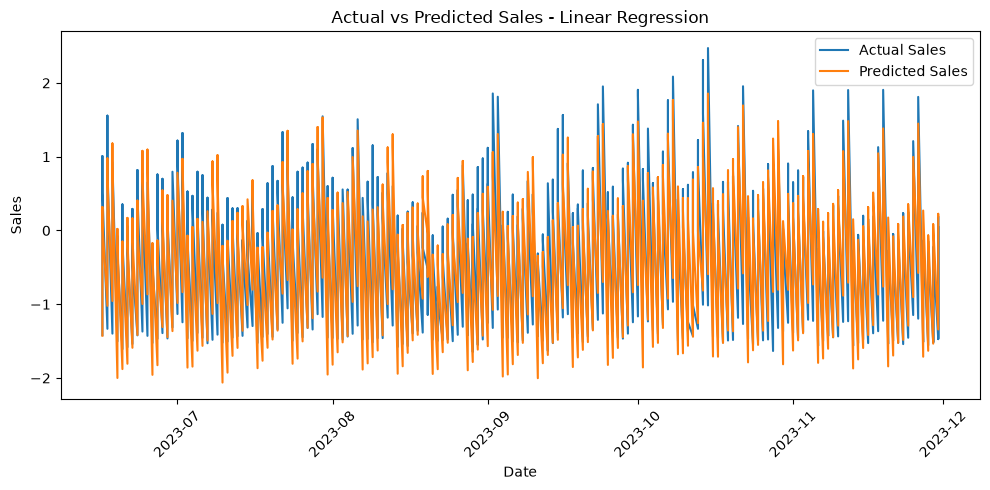

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(
    prediction_analysis["date"],
    prediction_analysis["sales"],
    label="Actual Sales"
)

plt.plot(
    prediction_analysis["date"],
    prediction_analysis["predicted_sales"],
    label="Predicted Sales"
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Actual vs Predicted Sales - Linear Regression")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
prediction_analysis["residual"] = (
    prediction_analysis["sales"]
    - prediction_analysis["predicted_sales"]
)

print("=" * 70)
print("RESIDUAL ANALYSIS")
print("=" * 70)

print(
    prediction_analysis["residual"].describe()
)

RESIDUAL ANALYSIS
count    1397.000000
mean        0.009035
std         0.347529
min        -1.394940
25%        -0.181699
50%         0.029604
75%         0.245417
max         1.322164
Name: residual, dtype: float64


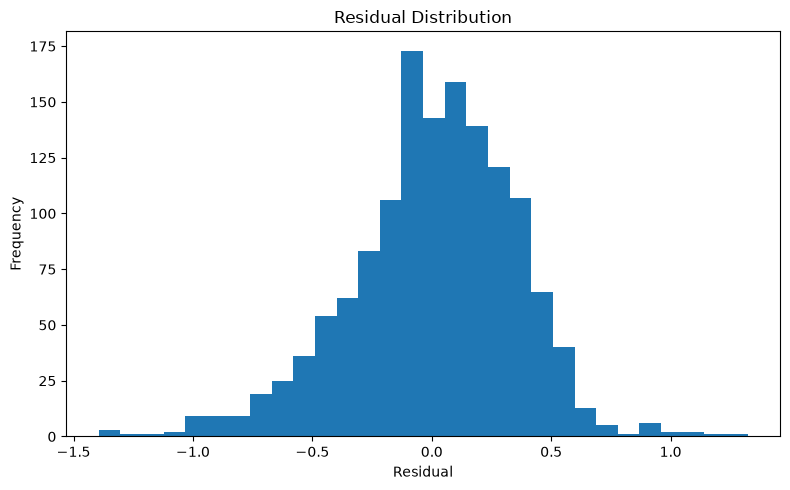

In [25]:
plt.figure(figsize=(8, 5))

plt.hist(
    prediction_analysis["residual"],
    bins=30
)

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")

plt.tight_layout()
plt.show()

In [26]:
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / "candidate_model.joblib"

joblib.dump(candidate_model, MODEL_PATH)

print("=" * 70)
print("MODEL SAVED")
print("=" * 70)

print("Model:", candidate_name)
print("Path :", MODEL_PATH)

MODEL SAVED
Model: Linear Regression
Path : ..\models\candidate_model.joblib


In [27]:
loaded_model = joblib.load(MODEL_PATH)

loaded_predictions = loaded_model.predict(X_validation)

print("=" * 70)
print("MODEL LOAD VERIFICATION")
print("=" * 70)

print("Model loaded successfully.")
print("Prediction count:", len(loaded_predictions))

print(
    "Predictions match:",
    np.allclose(candidate_predictions, loaded_predictions)
)

MODEL LOAD VERIFICATION
Model loaded successfully.
Prediction count: 1397
Predictions match: True


In [29]:
import json 
model_metadata = {
    "model_name": candidate_name,
    "target": TARGET,
    "features": MODEL_FEATURES,
    "mae": float(candidate_row["MAE"]),
    "rmse": float(candidate_row["RMSE"]),
    "r2": float(candidate_row["R2"]),
    "baseline_mae": float(baseline_mae),
    "baseline_rmse": float(baseline_rmse),
    "baseline_r2": float(baseline_r2)
}

METADATA_PATH = MODEL_DIR / "candidate_metadata.json"

with open(METADATA_PATH, "w") as f:
    json.dump(model_metadata, f, indent=4)

print("=" * 70)
print("MODEL METADATA SAVED")
print("=" * 70)

print(METADATA_PATH)

MODEL METADATA SAVED
..\models\candidate_metadata.json


In [30]:
print("=" * 70)
print("PHASE 3 - MODEL TRAINING AND SELECTION COMPLETED")
print("=" * 70)

print("\nModels evaluated:")
print("1. Weekly Lag Baseline")
print("2. Linear Regression")
print("3. Random Forest")
print("4. XGBoost")

print("\nSelected ML candidate:", candidate_name)

print("\nSelected ML model metrics:")
print(f"MAE  : {candidate_row['MAE']:.4f}")
print(f"RMSE : {candidate_row['RMSE']:.4f}")
print(f"R²   : {candidate_row['R2']:.4f}")

print("\nBaseline metrics:")
print(f"MAE  : {baseline_mae:.4f}")
print(f"RMSE : {baseline_rmse:.4f}")
print(f"R²   : {baseline_r2:.4f}")

print("\nModel saved at:")
print(MODEL_PATH)

print("\nMetadata saved at:")
print(METADATA_PATH)

PHASE 3 - MODEL TRAINING AND SELECTION COMPLETED

Models evaluated:
1. Weekly Lag Baseline
2. Linear Regression
3. Random Forest
4. XGBoost

Selected ML candidate: Linear Regression

Selected ML model metrics:
MAE  : 0.2686
RMSE : 0.3475
R²   : 0.8001

Baseline metrics:
MAE  : 0.2593
RMSE : 0.3830
R²   : 0.7572

Model saved at:
..\models\candidate_model.joblib

Metadata saved at:
..\models\candidate_metadata.json
